# Project overview

Beta Bank customers are leaving: little by little, chipping away every month. The bankers figured out it’s cheaper to save the existing customers rather than to attract new ones.

We need to predict whether a customer will leave the bank soon. You have the data on clients’ past behavior and termination of contracts with the bank.

Build a model with the maximum possible F1 score. To pass the project, you need an F1 score of at least 0.59. Check the F1 for the test set.

Additionally, measure the AUC-ROC metric and compare it with the F1.

Project instructions
Download and prepare the data. Explain the procedure.
Examine the balance of classes. Train the model without taking into account the imbalance. Briefly describe your findings.
Improve the quality of the model. Make sure you use at least two approaches to fixing class imbalance. Use the training set to pick the best parameters. Train different models on training and validation sets. Find the best one. Briefly describe your findings.
Perform the final testing.
Data description
The data can be found in /datasets/Churn.csv file. Download the dataset.

Features

RowNumber — data string index
CustomerId — unique customer identifier
Surname — surname
CreditScore — credit score
Geography — country of residence
Gender — gender
Age — age
Tenure — period of maturation for a customer’s fixed deposit (years)
Balance — account balance
NumOfProducts — number of banking products used by the customer
HasCrCard — customer has a credit card
IsActiveMember — customer’s activeness
EstimatedSalary — estimated salary
Target

Exited — сustomer has left

## Importing necessary components

In [1]:
# Import necessary files.
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, mean_squared_error, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Loading and prepping data

In [2]:
# Loading the data.
df_churn = pd.read_csv('datasets/Churn.csv')

In [3]:
# Checking the data.
display(df_churn.info())
display(df_churn)
display(df_churn.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


None

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5.0,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10.0,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7.0,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3.0,75075.31,2,1,0,92888.52,1


RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

In [4]:
# Reviewer's code

display(df_churn.head(3))

df_churn.tail(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9997,9998,15584532,Liu,709,France,Female,36,7.0,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3.0,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,NaN,130142.79,1,1,0,38190.78,0


In [5]:
# Checking the Tenure column.
display(df_churn['Tenure'])

0        2.0
1        1.0
2        8.0
3        1.0
4        2.0
        ... 
9995     5.0
9996    10.0
9997     7.0
9998     3.0
9999     NaN
Name: Tenure, Length: 10000, dtype: float64

In [6]:
# Filling in the NA values with median since the values are on a continuous range.
df_churn['Tenure'] = df_churn['Tenure'].fillna(df_churn['Tenure'].median())
display(df_churn['Tenure'])

0        2.0
1        1.0
2        8.0
3        1.0
4        2.0
        ... 
9995     5.0
9996    10.0
9997     7.0
9998     3.0
9999     5.0
Name: Tenure, Length: 10000, dtype: float64

In [7]:
display(df_churn.isna().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
# Dropping surname column. 
df_churn = df_churn.drop(columns=['Surname', 'RowNumber','CustomerId'])

In [9]:
# Encode categorical variables before splitting
data_encoded = pd.get_dummies(df_churn, drop_first=True)

In [10]:
# Further investigating the different columns
display(df_churn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  float64
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 859.5+ KB


None

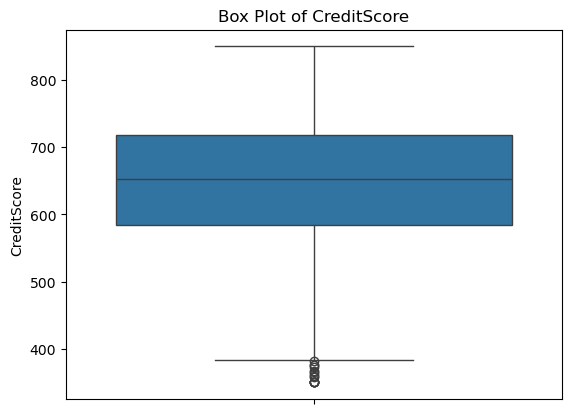

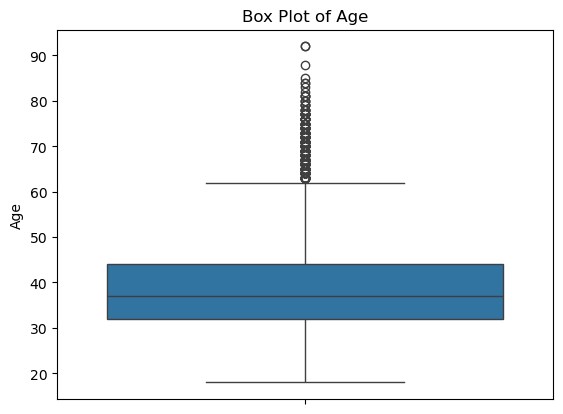

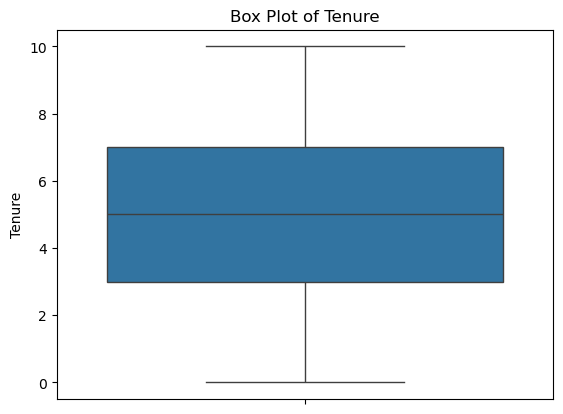

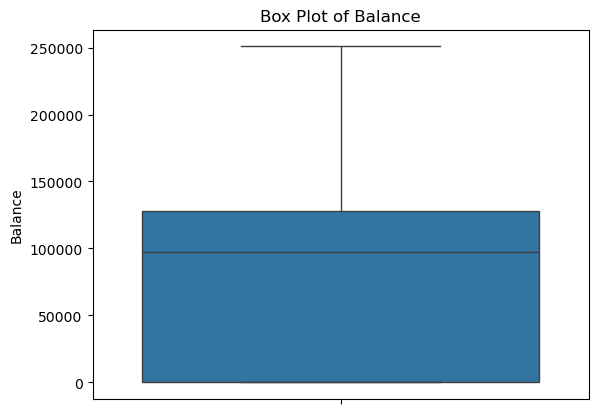

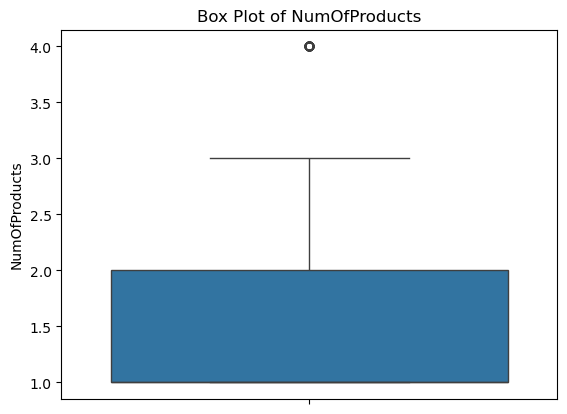

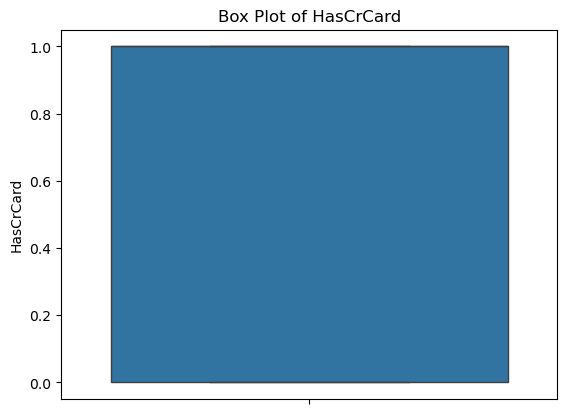

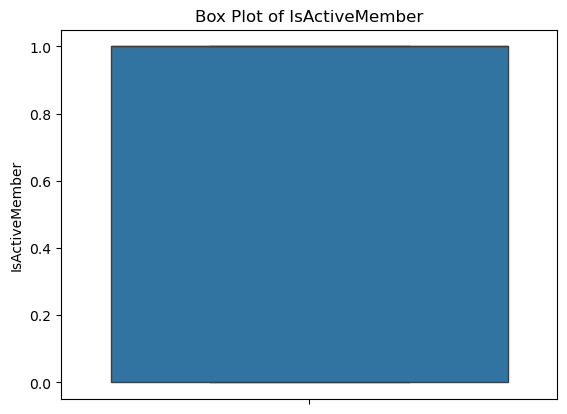

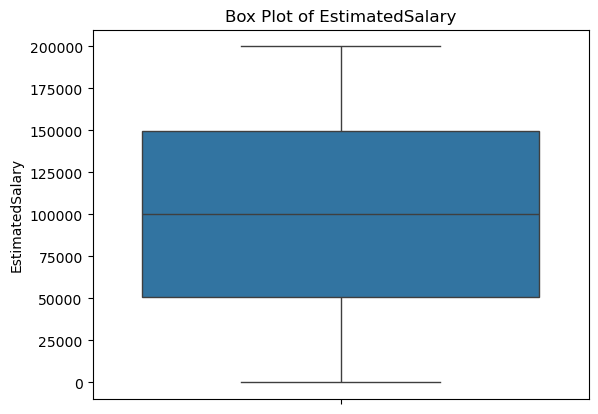

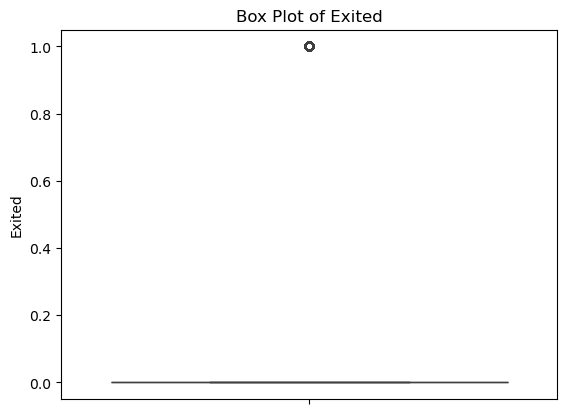

In [11]:
for column in df_churn.select_dtypes(include=['number']).columns:
    sns.boxplot(data=df_churn[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

The age column has several outliers above 60 years old. This lines up with the general public becoming having older people declining due to old age. In the future it might make sense to stratify the age segments in order to have more meaningful targeting of cohorts.

EstimatedSalary
24924.92     2
101348.88    1
55313.44     1
72500.68     1
182692.80    1
            ..
120893.07    1
188377.21    1
55902.93     1
4523.74      1
38190.78     1
Name: count, Length: 9999, dtype: int64

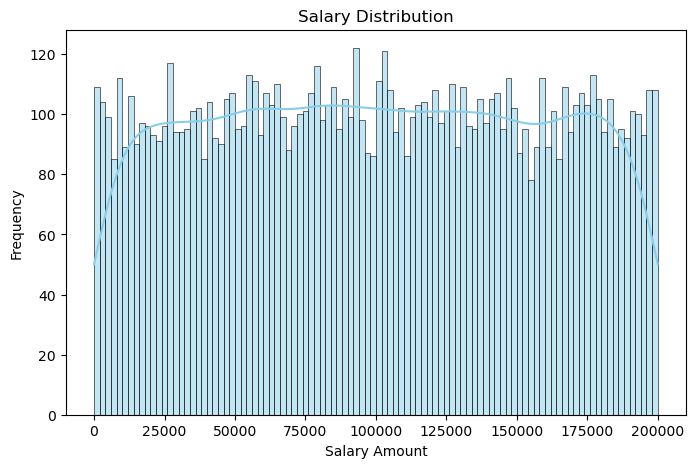

In [12]:
# Checking 'EstimatedSalary'
value_counts = df_churn['EstimatedSalary'].value_counts()
display(value_counts)

df_sorted = df_churn.sort_values(by='EstimatedSalary')

plt.figure(figsize=(8, 5))
sns.histplot(df_sorted['EstimatedSalary'], bins=100, kde=True, color='skyblue')

# Formatting
plt.title("Salary Distribution")
plt.xlabel("Salary Amount")
plt.ylabel("Frequency")
plt.show()


The salary distribution does not appear to be in line with the natural distribution with the rest of society. Normally we would expect to see a heavily right skewed distribution similar to the general population.

In [13]:
value_counts = df_churn['Exited'].value_counts()
display(value_counts)

Exited
0    7963
1    2037
Name: count, dtype: int64

In [14]:
# Define Featuers and targets
features = data_encoded.drop(columns=['Exited'])
target = data_encoded['Exited']

In [15]:
# Split the data
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.4, random_state=12345)
features_train, features_valid, target_train, target_valid = train_test_split(features_train, target_train, test_size=0.25, random_state=12345)

## Training models

In [16]:
# Train the model
model = DecisionTreeClassifier(class_weight='balanced', random_state=12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
probabilities = model.predict_proba(features_valid)[:, 1]
roc_auc = roc_auc_score(target_valid, probabilities)
f1 = f1_score(target_valid, predicted_valid)
display("F1 Score:", f1)
display("AUC-ROC:", roc_auc)

'F1 Score:'

0.47394957983193275

'AUC-ROC:'

np.float64(0.6716853342862567)

This score is lower than the threshold. Switching to Random Forest.

In [17]:
# Training the model again with Random Forest
model = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

probabilities = model.predict_proba(features_valid)[:, 1]
roc_auc = roc_auc_score(target_valid, probabilities)
f1 = f1_score(target_valid, predicted_valid)

display("F1 Score:", f1)
display("AUC-ROC:", roc_auc)

'F1 Score:'

0.5531914893617021

'AUC-ROC:'

np.float64(0.8412796346134518)

My decision tree achieved a score of .44 and the best my random forest was able to do was 0.54. The threshold for the requirement is 0.59. I will now tune the hyperparameters.

In [18]:
# Tuning the hyperparameters.
for depth in range(1, 25):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth) # create a model with the given depth
    model.fit(features_train, target_train) # train the model
    predictions = model.predict(features_valid) # get the model's predictions
    result = accuracy_score(target_valid, predictions) # calculate the accuracy
    print("max_depth =", depth, ":", result)
    probabilities = model.predict_proba(features_valid)[:, 1]
    roc_auc = roc_auc_score(target_valid, probabilities)
    f1 = f1_score(target_valid, predicted_valid)

    display("F1 Score:", f1)
    display("AUC-ROC:", roc_auc)



max_depth = 1 : 0.8013333333333333


'F1 Score:'

0.5531914893617021

'AUC-ROC:'

np.float64(0.6851109448458386)

...

max_depth = 24 : 0.79


'F1 Score:'

0.5531914893617021

'AUC-ROC:'

np.float64(0.6935672090140594)

## Downsampling

In [19]:
# Downsampling
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=12345)]
        + [features_ones]
    )
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=12345)]
        + [target_ones]
    )

    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345
    )

    return features_downsampled, target_downsampled


features_downsampled, target_downsampled = downsample(
    features_train, target_train, 0.1
)


model = RandomForestClassifier(class_weight='balanced',n_estimators=200, max_depth=None, random_state=12345, min_samples_split=10)
model.fit(features_downsampled, target_downsampled)
probabilities = model.predict_proba(features_valid)[:, 1]
threshold= 0.4
predicted_valid = (probabilities >= threshold).astype(int)

roc_auc = roc_auc_score(target_valid, probabilities)
f1 = f1_score(target_valid, predicted_valid)

display("F1 Score:", f1)
display("AUC-ROC:", roc_auc)

'F1 Score:'

0.44776119402985076

'AUC-ROC:'

np.float64(0.8301767747266859)

In [20]:
# Tuning the hyperparameters.
for depth in range(1, 25):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth) # create a model with the given depth
    model.fit(features_train, target_train) # train the model
    predictions = model.predict(features_valid) # get the model's predictions
    result = accuracy_score(target_valid, predictions) # calculate the accuracy
    print("max_depth =", depth, ":", result)
    f3 = f1_score(target_valid, predictions)
    threshold= 0.4
    predicted_valid = (probabilities >= threshold).astype(int)
    probabilities = model.predict_proba(features_valid)[:, 1]
    roc_auc = roc_auc_score(target_valid, probabilities)
    f1 = f1_score(target_valid, predictions)

    display("F1 Score:", f1)
    display("AUC-ROC:", roc_auc)


max_depth = 1 : 0.8013333333333333


'F1 Score:'

0.0

'AUC-ROC:'

np.float64(0.6851109448458386)

...

max_depth = 24 : 0.79


'F1 Score:'

0.5023696682464455

'AUC-ROC:'

np.float64(0.6935672090140594)

In [21]:
model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
threshold= 0.7
predicted_valid = (probabilities >= threshold).astype(int)
probabilities = model.predict_proba(features_valid)[:, 1]
roc_auc = roc_auc_score(target_valid, probabilities)
f1 = f1_score(target_valid, predicted_valid)

display("F1 Score:", f1)
display("AUC-ROC:", roc_auc)

'F1 Score:'

0.5023696682464455

'AUC-ROC:'

np.float64(0.715013567990709)

## Upsampling

In [22]:
# Upsampling
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    features_train, target_train, 20
)

model = RandomForestClassifier( n_estimators=300, max_depth=30, random_state=12345, max_features=2)
model.fit(features_upsampled, target_upsampled)
probabilities =model.predict_proba(features_valid)[:, 1]
threshold= 0.38
predicted_valid = (probabilities >= threshold).astype(int)

roc_auc = roc_auc_score(target_valid, probabilities)
f1 = f1_score(target_valid, predicted_valid)

display("F1 Score:", f1)
display("AUC-ROC:", roc_auc)

'F1 Score:'

0.5826771653543307

'AUC-ROC:'

np.float64(0.8407129057834258)

In [23]:
# Tuning the hyperparameters.
for depth in range(1, 30):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth, criterion='gini') # create a model with the given depth
    model.fit(features_train, target_train) # train the model
    predictions = model.predict(features_valid) # get the model's predictions
    result = accuracy_score(target_valid, predictions) # calculate the accuracy
    print("max_depth =", depth, ":", result)
    f3 = f1_score(target_valid, predictions)
    threshold= 0.35
    predicted_valid = (probabilities >= threshold).astype(int)
    probabilities = model.predict_proba(features_valid)[:, 1]
    roc_auc = roc_auc_score(target_valid, probabilities)
    f1 = f1_score(target_valid, predictions)

    display("F1 Score:", f1)
    display("AUC-ROC:", roc_auc)


max_depth = 1 : 0.8013333333333333


'F1 Score:'

0.0

'AUC-ROC:'

np.float64(0.6851109448458386)

...

max_depth = 29 : 0.79


'F1 Score:'

0.5023696682464455

'AUC-ROC:'

np.float64(0.6935672090140594)

In [24]:
# Trying GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']}

rf = RandomForestClassifier(random_state=12345)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='f1', cv=5)
grid_search.fit(features_train, target_train)
best_model = grid_search.best_estimator_

print(grid_search.best_params_)

predictions = best_model.predict(features_valid)
f1 = f1_score(target_valid, predictions)
print(f1)

{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
0.5935919055649241


In [25]:
model = RandomForestClassifier(class_weight='balanced', n_estimators=300, max_depth=10, random_state=12345, min_samples_split=10)
model.fit(features_train, target_train)
probabilities = model.predict_proba(features_valid)[:, 1]

# Setting up a range of thresholds
thresholds = np.arange(0.1, 0.9, 0.001)

best_f1 = 0
best_threshold = 0.5 

# Loop through thresholds to find the best one
for threshold in thresholds:
    predicted_valid = (probabilities >= threshold).astype(int)
    f1 = f1_score(target_valid, predicted_valid)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best Threshold: {best_threshold}, Best F1 Score: {best_f1}")


Best Threshold: 0.4520000000000003, Best F1 Score: 0.6144393241167435


In [26]:
model = RandomForestClassifier(class_weight='balanced', n_estimators=300, max_depth=10, random_state=12345, min_samples_split=10)
model.fit(features_train, target_train)
probabilities =model.predict_proba(features_valid)[:, 1]
threshold= 0.444000000000000003
predicted_valid = (probabilities >= threshold).astype(int)

roc_auc = roc_auc_score(target_valid, probabilities)
f1 = f1_score(target_valid, predicted_valid)

display("F1 Score:", f1)
display("AUC-ROC:", roc_auc)

'F1 Score:'

0.6077844311377245

'AUC-ROC:'

np.float64(0.8471702643245598)

In [27]:
# Final Test
model = RandomForestClassifier(class_weight='balanced', n_estimators=300, max_depth=10, random_state=12345, min_samples_split=10)
model.fit(features_train, target_train)
probabilities =model.predict_proba(features_test)[:, 1]
threshold= 0.444000000000000003
predicted_test = (probabilities >= threshold).astype(int)

roc_auc = roc_auc_score(target_test, probabilities)
f1 = f1_score(target_test, predicted_test)

display("F1 Score:", f1)
display("AUC-ROC:", roc_auc)

'F1 Score:'

0.6078740157480315

'AUC-ROC:'

np.float64(0.8571200040350523)

In [28]:
importances = model.feature_importances_
print(importances)


[0.08268862 0.31014791 0.04734104 0.12076572 0.1868609  0.0106536
 0.05932835 0.08629415 0.06121572 0.0094257  0.02527829]


## Wrap up

After tuning the hyperparameters like a madman and then resorting to using gridsearchcv I was able to achieve the F1 0.6075959... for a final test. model = RandomForestClassifier(class_weight='balanced', n_estimators=300, max_depth=10, random_state=12345, min_samples_split=10) with a threshold = 0.444000000000000003

I look into the model.feature_importances_ and here were the top features:

Geography = 0.30951888 - This has the most weight on churn. This may be due to regional competition or quality of our service relative the rest of the market.

Age = 0.12087781 - This may indicate that users might be aging out of using our service or something else. This would require additional tests to pinpoint which age group is most affected.

Tenure =  0.18583478 - This one needs further clarification but it might show that users who have more loyalty are not jumping ship for greener pastures.
